# آموزش مدل تشخیص احساس از چهره (FER-CNN)

**دیتاست:** [facial_expressions](https://github.com/muxspace/facial_expressions)
(عکس‌های واقعی چهره - عمدتاً LFW - با برچسب احساس). این دقیقاً FER2013 نیست
(که به دسترسی Kaggle نیاز داره)، ولی داده‌ی واقعی و برچسب‌خورده‌ست و روی همون
۷ کلاس پروژه نگاشت می‌شه.

برای هر عکس، از **همون تشخیص‌گر چهره‌ی خود پروژه** (`vision.face_detector`)
برای crop کردن چهره استفاده می‌کنیم - دقیقاً همون‌جوری که موقع inference واقعی
عمل می‌کنه.

**نکته‌ی مهم:** این دیتاست شدیداً نامتوازنه (فقط ۲۱ نمونه‌ی fear در مقابل
هزاران happy/neutral). یک تلاش اول با معماری بزرگ‌تر (که در سند طراحی اولیه
پیشنهاد شده بود) کاملاً روی کلاس‌های اکثریت collapse کرد. معماری سبک‌تر و
regularize‌شده‌ی این نوت‌بوک بهتر جواب داد، ولی fear همچنان به‌خاطر کمبود
داده‌ی واقعی قابل‌اعتماد یاد گرفته نمی‌شه - این یک محدودیت داده‌ست، نه باگ.

In [1]:
import csv
from pathlib import Path
import sys

import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
from config import EMOTIONS, FER_INPUT_SIZE, WEIGHTS_DIR
from vision.face_detector import FaceDetector

tf.random.set_seed(0)
np.random.seed(0)

ROOT = Path.cwd().parent
DATASET_DIR = ROOT / "facial_expressions"
IMAGES_DIR = DATASET_DIR / "images"
LEGEND_CSV = DATASET_DIR / "data" / "legend.csv"
CACHE_PATH = ROOT / "dataset_vision_cache.npz"

LABEL_MAP = {
    "anger": "angry", "ANGER": "angry",
    "disgust": "disgust", "DISGUST": "disgust",
    "fear": "fear", "FEAR": "fear",
    "happiness": "happy", "HAPPINESS": "happy",
    "sadness": "sad", "SADNESS": "sad",
    "surprise": "surprise", "SURPRISE": "surprise",
    "neutral": "neutral", "NEUTRAL": "neutral",
}
MAX_PER_CLASS = 1200
MIN_PER_CLASS_AUGMENTED = 250
EPOCHS = 25
BATCH_SIZE = 32

I0000 00:00:1788674464.236899     627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788674464.317772     627 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788674465.794261     627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## بارگذاری و پیش‌پردازش (با کش، چون تشخیص چهره روی هزاران عکس کند است)

In [2]:
def load_rows():
    rows = []
    with open(LEGEND_CSV, encoding="utf-8") as f:
        for r in csv.DictReader(f):
            emo = LABEL_MAP.get(r["emotion"])
            if emo:
                rows.append((r["image"], emo))
    return rows

def cap_per_class(rows):
    by_class = {}
    for img, emo in rows:
        by_class.setdefault(emo, []).append(img)
    kept = []
    for emo, imgs in by_class.items():
        if len(imgs) > MAX_PER_CLASS:
            rng = np.random.default_rng(0)
            imgs = list(rng.choice(imgs, size=MAX_PER_CLASS, replace=False))
        kept += [(img, emo) for img in imgs]
        print(f"  {emo:9s} using {len(imgs)} / {len(by_class[emo])} available")
    return kept

def build_dataset(rows):
    detector = FaceDetector()
    print("face detector backend:", detector._backend)
    X, y = [], []
    n_no_face = 0
    for i, (fname, emo) in enumerate(rows):
        img = cv2.imread(str(IMAGES_DIR / fname))
        if img is None:
            continue
        face, conf = detector.detect(img)
        if face is None:
            n_no_face += 1
            continue
        gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, FER_INPUT_SIZE)
        X.append(gray.astype("float32") / 255.0)
        y.append(EMOTIONS.index(emo))
    print(f"done. {len(X)} usable faces, {n_no_face} images with no detected face.")
    return np.stack(X)[..., np.newaxis], np.array(y)

if CACHE_PATH.exists():
    print(f"Loading cached preprocessed dataset from {CACHE_PATH}")
    data = np.load(CACHE_PATH)
    X, y = data["X"], data["y"]
else:
    rows = cap_per_class(load_rows())
    X, y = build_dataset(rows)
    np.savez_compressed(CACHE_PATH, X=X, y=y)

print("X shape:", X.shape)
for i, e in enumerate(EMOTIONS):
    print(f"  {e:9s} {(y==i).sum()}")

Loading cached preprocessed dataset from /home/claude/dataset_vision_cache.npz


X shape: (2937, 48, 48, 1)
  angry     213
  disgust   23
  fear      14
  happy     1078
  sad       135
  surprise  340
  neutral   1134


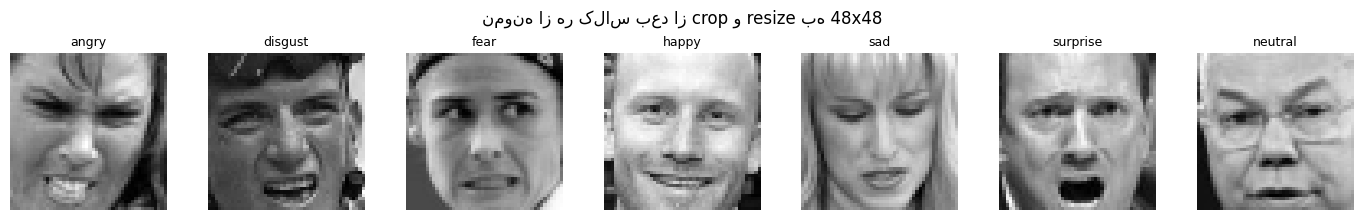

In [3]:
fig, axes = plt.subplots(1, 7, figsize=(14, 2.2))
rng = np.random.default_rng(1)
for i, e in enumerate(EMOTIONS):
    idx = np.where(y == i)[0]
    ax = axes[i]
    if len(idx):
        pick = rng.choice(idx)
        ax.imshow(X[pick, :, :, 0], cmap="gray")
    ax.set_title(e, fontsize=9)
    ax.axis("off")
plt.suptitle("نمونه از هر کلاس بعد از crop و resize به 48x48")
plt.tight_layout()
plt.show()

## تفکیک train/val/test + oversampling کلاس‌های کم‌نمونه

validation از داده‌ی واقعی (قبل از oversample) جدا می‌شود تا معیار ارزیابی تمیز بماند.

In [4]:
def augment_batch(imgs, rng):
    out = imgs.copy()
    if rng.random() < 0.5:
        out = out[:, :, ::-1, :]
    out = np.clip(out + rng.uniform(-0.08, 0.08), 0.0, 1.0)
    sx, sy = rng.integers(-3, 4, size=2)
    out = np.roll(out, shift=(sx, sy), axis=(1, 2))
    return out

def oversample_minority_classes(X, y):
    rng = np.random.default_rng(0)
    Xs, ys = [X], [y]
    for cls in range(len(EMOTIONS)):
        idx = np.where(y == cls)[0]
        n = len(idx)
        if 0 < n < MIN_PER_CLASS_AUGMENTED:
            n_needed = MIN_PER_CLASS_AUGMENTED - n
            picks = rng.choice(idx, size=n_needed, replace=True)
            aug = augment_batch(X[picks], rng)
            Xs.append(aug); ys.append(np.full(n_needed, cls))
            print(f"  oversampled {EMOTIONS[cls]:9s} {n} -> {n + n_needed}")
    return np.concatenate(Xs), np.concatenate(ys)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=0, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=0, stratify=y_trainval)
X_train, y_train = oversample_minority_classes(X_train, y_train)
perm = np.random.default_rng(0).permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.arange(len(EMOTIONS)), y=y_train)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
class_weight

  oversampled angry     154 -> 250
  oversampled disgust   16 -> 250
  oversampled fear      10 -> 250
  oversampled sad       98 -> 250
  oversampled surprise  246 -> 250


{0: np.float64(1.6268571428571428),
 1: np.float64(1.6268571428571428),
 2: np.float64(1.6268571428571428),
 3: np.float64(0.5227690047741461),
 4: np.float64(1.6268571428571428),
 5: np.float64(1.6268571428571428),
 6: np.float64(0.4965986394557823)}

## معماری مدل

معماری سبک‌تر از پیشنهاد اولیه‌ی سند طراحی: GlobalAveragePooling + L2 + dropout بیشتر، چون معماری بزرگ‌تر (Flatten + Dense(128)) روی این حجم داده (~۳ هزار عکس واقعی) سریع overfit/collapse می‌کرد.

In [5]:
def build_fer_cnn():
    reg = regularizers.l2(1e-4)
    m = models.Sequential([
        layers.Input(shape=(*FER_INPUT_SIZE, 1)),
        layers.Conv2D(16, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dropout(0.3),
        layers.Dense(len(EMOTIONS), activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

model = build_fer_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,359 (110.78 KB)

 Trainable params: 28,135 (109.90 KB)

 Non-trainable params: 224 (896.00 B)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    X_train, tf.keras.utils.to_categorical(y_train, len(EMOTIONS)),
    validation_data=(X_val, tf.keras.utils.to_categorical(y_val, len(EMOTIONS))),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight, callbacks=callbacks, verbose=2,
)

Epoch 1/25


89/89 - 5s - 52ms/step - accuracy: 0.2227 - loss: 1.9943 - val_accuracy: 0.3867 - val_loss: 1.9072 - learning_rate: 0.0010


Epoch 2/25


89/89 - 5s - 53ms/step - accuracy: 0.3073 - loss: 1.6784 - val_accuracy: 0.3813 - val_loss: 1.7939 - learning_rate: 0.0010


Epoch 3/25


...

89/89 - 3s - 29ms/step - accuracy: 0.6955 - loss: 0.6358 - val_accuracy: 0.5307 - val_loss: 1.2411 - learning_rate: 5.0000e-04


Epoch 24/25


89/89 - 2s - 27ms/step - accuracy: 0.7095 - loss: 0.6112 - val_accuracy: 0.5360 - val_loss: 1.1795 - learning_rate: 2.5000e-04


Epoch 25/25


89/89 - 3s - 29ms/step - accuracy: 0.7250 - loss: 0.5719 - val_accuracy: 0.4773 - val_loss: 1.2893 - learning_rate: 2.5000e-04


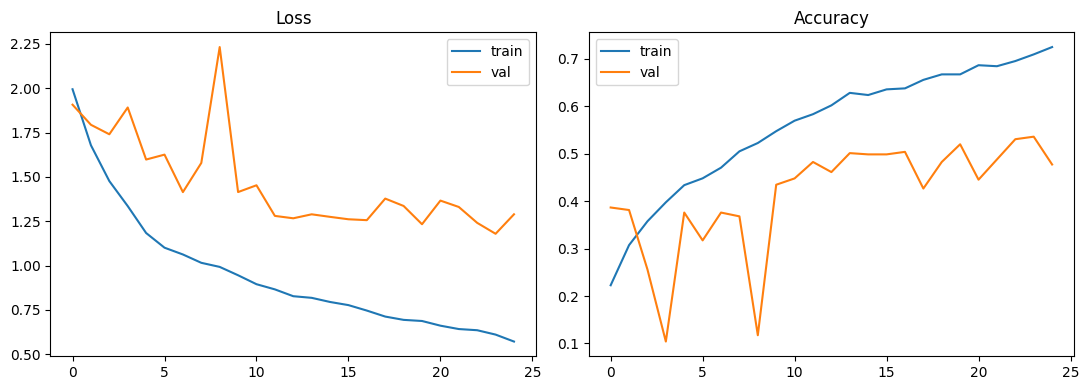

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

## ارزیابی روی داده‌ی تست

توجه: `fear` و `disgust` تعداد نمونه‌ی تست بسیار کمی دارند (به ترتیب ۲ و ۴ نمونه) - معیارها روی این دو کلاس عملاً نویزی‌اند، نه یک ارزیابی قابل‌اعتماد.

In [8]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=EMOTIONS, digits=2, zero_division=0))

              precision    recall  f1-score   support

       angry       0.29      0.22      0.25        32
     disgust       0.00      0.00      0.00         4
        fear       0.00      0.00      0.00         2
       happy       0.64      0.80      0.71       162
         sad       0.11      0.10      0.11        20
    surprise       0.39      0.75      0.51        51
     neutral       0.67      0.38      0.48       170

    accuracy                           0.55       441
   macro avg       0.30      0.32      0.29       441
weighted avg       0.57      0.55      0.53       441



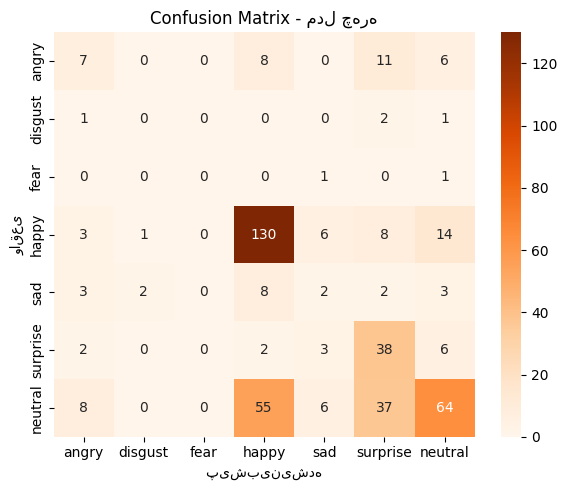

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(EMOTIONS)))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax)
ax.set_xlabel("پیش‌بینی‌شده"); ax.set_ylabel("واقعی")
ax.set_title("Confusion Matrix - مدل چهره")
plt.tight_layout()
plt.show()

## ذخیره‌ی وزن‌ها

خروجی: `weights/fer_cnn.weights.h5` — دقیقاً همون فایلی که `vision/fer_model.py` لود می‌کنه.

In [10]:
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
model.save_weights(str(WEIGHTS_DIR / "fer_cnn.weights.h5"))
print("saved.")

saved.
